## NumPy & SciPy – spielerische Einführung mit Bildverarbeitung
---

Bei Fragen gerne jederzeit unter https://wa.me/4917621690670 melden.
In diesem Notebook lernst du:

- was ein `np.array()` ist und wie Bilder als arrays funktionieren
- wie man **eigene Bilder** mit NumPy “malt”  
- wie man Bilder **anzeigt** und **ausschneidet (crop)**  
- wie man mit **Korrelation** (`scipy.signal.correlate2d`) einfache Features in Bildern findet


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate2d

### 1. Theorie: Arrays als Bilder und Bilder als Arrays
---

Ein Graustufenbild kann man als 2D-Array verstehen:

- Höhe = Anzahl Zeilen  
- Breite = Anzahl Spalten  
- jeder Eintrag ist ein **Helligkeitswert**

Wir starten mit zwei einfachen “Mini-Bildern” aus Zahlen.

In [3]:
I1 = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 0, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0],
])

I2 = np.array([
    [ 0,  1,  2,  3,  4],
    [ 5,  6,  7,  8,  9],
    [10, 11, 12, 13, 14],
    [15, 16, 17, 18, 19],
    [20, 21, 22, 23, 24],
])


- Ein Bild kannst Du mit `plt.imshow()` anzeigen lassen
- `cmap='gray'` macht Graustufen  
- `vmin` und `vmax` geben optional den minmalen Wert (weiss) und maximalen Wert (schwarz) an


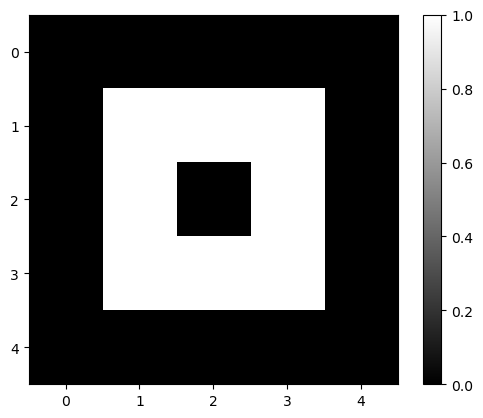

In [4]:
plt.imshow(I1, cmap='gray')
#plt.imshow(I2, cmap="gray", vmin=0, vmax=24)
#plt.axis("off")
plt.colorbar()
plt.show()

### 1. Übung: Arrays als Bilder und Bilder als Arrays
---

Erzeuge ein 5 mal 5 Bild mit schwarzen Hintergrund und einem zentrierten '+' Zeichen. Lasse das Bild anzeigen.

In [16]:
################
# Your code here
################

### 2.Theorie: Bilder laden und bearbeiten
---

Wenn du eine Bilddatei hast (z. B. `bild.png` im gleichen Ordner), kannst du sie so laden:

```python
img_rgb = plt.imread("bild.png")
```

Viele Bilder sind **RGB** (3 Kanäle für die Farben **R**ot, **G**rün und **B**lau). Dann ist die Form `(H, W, 3)`.


Form RGB: (500, 700, 3)
Form Gray: (500, 700)


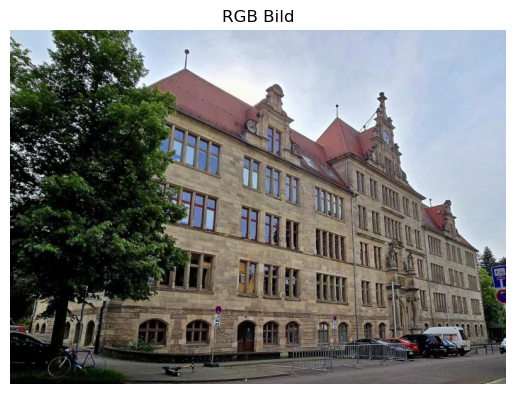

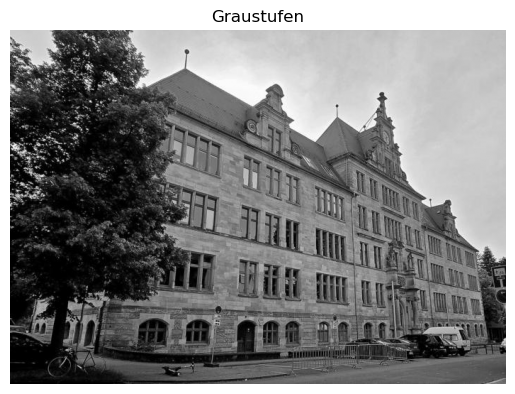

In [14]:
#Bilder einladen
I_rgb = plt.imread('Bilder/Parler_RGB.jpg')
I_gray = plt.imread('Bilder/Parler_Gray.jpg')
print("Form RGB:", I_rgb.shape)
print("Form Gray:", I_gray.shape)

plt.imshow(I_rgb)
plt.title("RGB Bild")
plt.axis("off")
plt.show()

plt.imshow(I_gray, cmap="gray")
plt.title("Graustufen")
plt.axis("off")
plt.show()


**Cropping: Ein Bildausschnitt**: Croppen heißt: wir nehmen nur einen Bereich aus dem Bild heraus.

Merke: `I[z0:z1, s0:s1]` (erst Zeilen = z, dann Spalten = s)


### 2.Übung: Bilder laden und bearbeiten
---

Schneide vom Bild `Bilder/Parler_Gray.jpg` das Fahrrad aus, das ganz links unten in der Nähe des Baums steht und lasse es anzeigen.

In [17]:
################
# Your code here
################

### 3. Eine einfache Version von Mustererkennung auf Bildern
---

**Suchbild**: Jetzt bauen wir ein größeres Bild mit mehreren “Ziffern”-ähnlichen Mustern.

- Hintergrund = 0  
- Vordergrund = 1  
- Die **1** ist ein senkrechter Strich  
- Die **8** ist ein Ring + Ring 
- Die **9** ist ein Ring + senkrechter Strich 


In [44]:
I = plt.imread('Bilder/Suchbild.png')

**Filter (kleine “Schablonen”)**: Wir bauen zwei Filter:

1. **Kreis-Filter**: erkennt ringförmige Strukturen  
2. **Strich-Filter**: erkennt vertikale Linien

Diese Filter sind kleine 2D-Arrays. Wir schieben sie über das Bild und berechnen an jeder Position eine Ähnlichkeit. Das macht `scipy.correlate2d`.


In [39]:
circle_filter = plt.imread('Bilder/circle_filter.png')
line_filter   = plt.imread('Bilder/line_filter.png')

**Berechne Korrelationen/Template Matching**

`correlate2d(scene, template, mode="same")` liefert eine Karte gleicher Größe wie `scene`.

- hohe Werte = Template passt gut an dieser Stelle  
- wir zeigen die Korrelation als Heatmap


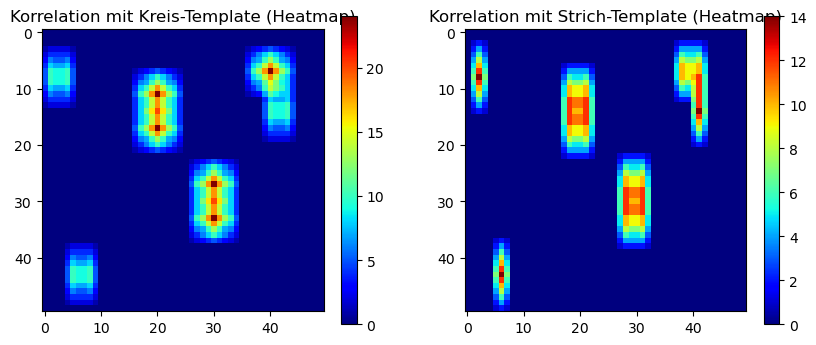

In [41]:
corr_circle = correlate2d(I, circle_filter, mode="same")
corr_line   = correlate2d(I, line_filter,   mode="same")

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.imshow(corr_circle,cmap='jet')
plt.colorbar()
plt.title("Korrelation mit Kreis-Template (Heatmap)")

plt.subplot(1,2,2)
plt.imshow(corr_line,cmap='jet')
plt.colorbar()
plt.title("Korrelation mit Strich-Template (Heatmap)")

plt.show()


**Peaks finden: Wo ist die beste Übereinstimmung?**

Wir suchen einfach die größten Werte.


In [42]:
circle_y, circle_x = np.where(corr_circle == np.max(corr_circle))
line_y, line_x = np.where(corr_line == np.max(corr_line))

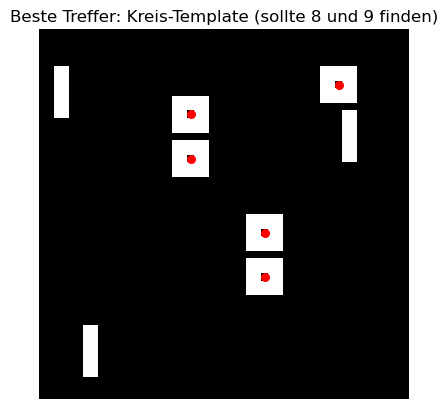

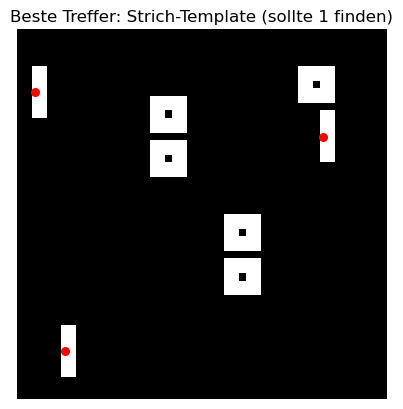

In [43]:
def show_peaks_on_scene(I, x, y, title):
    #plt.figure(figsize=(8, 4))
    plt.imshow(I, cmap="gray", vmin=0, vmax=1)
    plt.title(title)
    plt.axis("off")
    plt.scatter(x, y, s=30, marker="o", facecolors="red", edgecolors="red")
    plt.show()

show_peaks_on_scene(I, circle_x, circle_y, "Beste Treffer: Kreis-Template (sollte 8 und 9 finden)")
show_peaks_on_scene(I, line_x, line_y,   "Beste Treffer: Strich-Template (sollte 1 finden)")
